# Влияние learning rate и масштаба признаков на сходимость

In [1]:
import tensorflow as tf
print("TF", tf.__version__)
from matplotlib import animation, rc
import matplotlib.pyplot as plt
from IPython.display import HTML, display_html
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import clear_output, display_html, HTML
import contextlib
import time
import io
import urllib
import base64
import keras
from keras import backend as K

I0000 00:00:1778943587.776247  203111 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF 2.21.0


In [ ]:
def clear_and_display_figure(fig, sleep=0.01):
    img_data = io.BytesIO()
    fig.savefig(img_data, format='jpeg')
    img_data.seek(0)
    uri = 'data:image/jpeg;base64,' + urllib.request.quote(base64.b64encode(img_data.getbuffer()))
    img_data.close()
    clear_output(wait=True)
    display_html(HTML('<img src="' + uri + '">'))
    time.sleep(sleep)

In [20]:
import matplotlib.animation as animation

class SimpleMovieWriter(animation.MovieWriter):
    """
    Исправленная версия кастомного райтера анимаций для Colab / Jupyter
    """
    def __init__(self, sleep=0.1):
        self.sleep = sleep
        self.fig = None

    def setup(self, fig, outfile, dpi=None, *args, **kwargs):
        self.fig = fig

    def grab_frame(self, **kwargs):
        clear_and_display_figure(self.fig, self.sleep)

    @contextlib.contextmanager
    def saving(self, fig, outfile, dpi, *args, **kwargs):
        self.setup(fig, outfile, dpi)
        try:
            yield self
        finally:
            pass

    def _supports_transparency(self):
        return False


In [10]:
def reset_tf_session():
    # Модуль совместимости для старого синтаксиса TensorFlow
    import tensorflow.compat.v1 as tf
    tf.disable_eager_execution()
    
    # Прямой импорт функции set_session для Keras 3
    from tensorflow.python.keras.backend import set_session
    
    # Безопасно закрываем старую сессию
    try:
        curr_session = tf.get_default_session()
        if curr_session is not None:
            curr_session.close()
    except Exception:
        pass
        
    # Очищаем сессию Keras
    import tensorflow.keras.backend as K
    K.clear_session()
    
    # Настраиваем GPU и создаем новую сессию
    config = tf.ConfigProto()
    config.gpu_options.allow_growth = True
    s = tf.InteractiveSession(config=config)
    
    # Принудительно связываем сессию
    set_session(s)
    return s


In [11]:
# скидываем сессию
s = reset_tf_session()

Лосс на одном объекте: $l = (x_1 w_1 + x_2 w_2 - y)^2$

[Каноническое уравнение эллипса](https://ru.wikipedia.org/wiki/Эллипс): $\frac{x_1^2}{a^2} + \frac{x_2^2}{b^2} = 1$, поэтому [линии уровня](https://foxford.ru/wiki/matematika/metod-liniy-urovnya) лосса так выглядят.

Если мы будем увеличивать масштаб $x_1$, это будет сплющивать ось $w_1$ на графике линий уровня.

Разные по масштабу градиенты если разный масштаб признаков:

$ \frac{dl}{dw_1} = 2 (x_1 w_1 + x_2 w_2 - y) x_1$

$ \frac{dl}{dw_2} = 2 (x_1 w_1 + x_2 w_2 - y) x_2$

<a list of 22 text.Text objects>

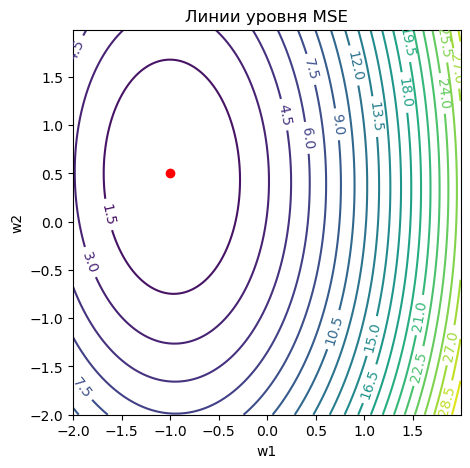

In [12]:
# генерируем простой датасет
np.random.seed(42)
N = 100
x = np.random.randn(N, 2)
w = np.array([[-1, 0.5]]).T
x[:, 0] *= 2  # признак x1 в x_scale раз больше (создает долины в лоссе)
y = x @ w + np.random.randn(N, 1) * 0.2
    
# рисуем линии уровня лосса в пространстве весов
fig, ax = plt.subplots(figsize=(5, 5))
W1, W2 = np.meshgrid(np.arange(-2, 2, 0.01), np.arange(-2, 2, 0.01))
Z = np.mean((x.dot(np.vstack([W1.ravel(), W2.ravel()])) - y)**2, axis=0).reshape(W1.shape)
contour = ax.contour(W1, W2, Z, 20)
ax.scatter(*w, c='red')
plt.xlabel('w1')
plt.ylabel('w2')
plt.title(u"Линии уровня MSE")
ax.clabel(contour, inline=1, fontsize=10)

In [16]:
def plot_gd(x_scale, lr, steps, optimizer='sgd'):
    # Импортируем модуль совместимости локально для безопасности
    import tensorflow.compat.v1 as tf
    
    # генерируем простой датасет
    np.random.seed(42)
    N = 100
    x = np.random.randn(N, 2)
    w = np.array([[-1, 0.5]]).T
    x[:, 0] *= x_scale  # признак x1 в x_scale раз больше (создает долины в лоссе)
    y = x @ w + np.random.randn(N, 1) * 0.2
    
    # оптимизация в TF
    # w_guess делаем вектором-столбцом [[1.5], [1.5]] для корректного матричного умножения
    w_guess = tf.Variable([[1.5], [1.5]], dtype='float32')  
    
    # Исправлено: используем tf.matmul для матричного умножения x @ w_guess вместо '*'
    loss = tf.reduce_mean((tf.matmul(tf.constant(x, tf.float32), w_guess) - tf.constant(y, tf.float32)) ** 2)
    
    # Исправлено: берем старые оптимизаторы из модуля tf.compat.v1.train
    if optimizer == 'sgd':
        step = tf.compat.v1.train.GradientDescentOptimizer(lr).minimize(loss, var_list=w_guess)
    elif optimizer == 'adam':
        step = tf.compat.v1.train.AdamOptimizer(lr).minimize(loss, var_list=w_guess)

    # рисуем линии уровня лосса в пространстве весов
    fig, ax = plt.subplots(figsize=(5, 5))
    W1, W2 = np.meshgrid(np.arange(-2, 2, 0.01), np.arange(-2, 2, 0.01))
    Z = np.mean((x.dot(np.vstack([W1.ravel(), W2.ravel()])) - y)**2, axis=0).reshape(W1.shape)
    contour = ax.contour(W1, W2, Z, 20)
    ax.scatter(*w, c='red')
    ax.clabel(contour, inline=1, fontsize=10)
    plt.xlabel('w1')
    plt.ylabel('w2')
    plt.title("Линии уровня MSE")
    line, = ax.plot([], [], lw=2)
    
    # Исправлено: инициализатор глобальных переменных тоже берем из compat.v1
    s.run(tf.compat.v1.global_variables_initializer())

    # стартуем анимацию с пустой траекторией
    def init():
        line.set_data([], [])
        return (line,)

    # Извлекаем значения w1 и w2 из вектора-столбца
    current_w = s.run(w_guess).flatten()
    trajectory = [(current_w[0], current_w[1])]

    # один шаг анимации (шаг бекпроп)
    def animate(i):
        s.run(step)
        current_w = s.run(w_guess).flatten()
        trajectory.append((current_w[0], current_w[1]))
        line.set_data(*zip(*trajectory))
        return (line,)

    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                   frames=steps, interval=20, blit=True)

    anim.save(None, writer=SimpleMovieWriter(0.0001))


# Простой SGD

У наивного SGD есть проблемы, он плохо сходится когда производные по разным весам слишком разные по масштабу!

<img src="%2BTl5ufo6erx8vP09fb3%2BPn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3%2BPn6/9oADAMBAAIRAxEAPwD3%2BiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACivOk8PaN4k%2BKviX%2B1tMtb5LSyskT7REH2M3mMcZ6cY/SqXgzWZ9D%2BHngqG1jhKX%2BqvZSB1PyxlrhsrgjByg65HXigD1KiuC0bx3fa14v1KzhtrddGjsHubGchvMuNknll%2BuNhYNjjJABzzWe3xXtG%2BHVpq0Op6I/iCZLffYCcEhnkRXAjD7%2BFLHGeMc0Aem0Vx%2BoeNG0nW/EFvdxI9tptpay26Rg%2BbPLMZFEY5wSWVQMDvWXpvjjXJfDWmXl/a2Ed/Nr40m5jiVjGq%2BaY2K/Nndx1zj2oA9Eorh9I8bXmsfESXSILaAaH9lmaC6wfMnlidEcqc42ZcqOOSpOcVs%2BK9buvDtnZ6kkcL2CXcceoFwd0cLnb5ikHjaxUnIPGaAN%2BiuQ1DxVfJqviKGwit3s9E00zSySKxLXRUuqDBA2hACe/zDkVlW/i/xRa6HoniLVrTShpWoNbrNDbiQTQCbAWTcSQRlgSuMgHGTjNAHolFcSfEHifWdQ1keHbfS1tNKuGtMXokZ7qZVDOFKkBANwAJDZPaszUfiNNNb%2BFLqwvdI0m11u1nnln1dSyxNGI8ICJEGcuw98CgD0mivOf8AhYOop8PrrxDJFYb7fUktFuF3fZriIzIhmTJBC4ZsckZXuK1n8d6feeMdC0fRdT0vUIL0XBujbzrK8WxAyY2tgZOeoOccUAdhRXkmu/E7VrCDWriK98PWU2n3b28WlXqObuZVcKHH7xeGB3DCkY7163QAUV4V8P8AXG8EeDpiwMialYtf6fGf47pZPJaIf7xMBx/tNWh4a8Oava%2BDvHGhaRcu2rLfRgyiXY0r%2BVC0uH/hL/OAe26gD2WivNPDU/hOx8SWFtJ4TvvDesyBlt2uYiqTttO5RIrFZDjP3ufxxWJomnaRdal4mkvvANxrk39u3Y%2B1xwWzjG/7uZJFbj6Y5oA9moqG0jjisoI4oPs8aRqqQ4A8sAcLgccdOKmoAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiis3xBqh0Pw5qerCETGytZbjyi23fsUtjODjOPSgDSorlrbU/G1xbpK/hrR4Cwz5cusPuH1225H61N9t8Z/8AQB0P/wAHEv8A8jUAdHRXOfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1UdQ8TeINKXdf2Phq27gS67IpP0H2fJppN7AdjRXlx%2BKesSymPTvDlnqbg4Isr2d/52wrWs/FPjy8AI8BQQqe82rhMfgYs/pVOnJboLnd0VzSX/jRlBPh/REPodYkyPyt6d9t8Z/8AQB0P/wAHEv8A8jVAHR0Vzn23xn/0AdD/APBxL/8AI1H23xn/ANAHQ/8AwcS//I1AHR02QO0bCNgjkEKxGcH1x3rnvtvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoAn8N%2BHBoIvZ572W/wBSv5hNd3cqhTIwUKoCjhVAGAK5y7%2BGbXXgnR/Da63JB/Z961011FBhpFbzdyAbvkOJSN2TjGcVufbfGf8A0AdD/wDBxL/8jVXudV8cQDMfhXSbg%2BkWssP/AEKAUAWU8JwQa8uoWsqwW6aT/ZcdqsXCKH3Bgc9hxjH41nyeAIX%2BHdr4VF4iyQJAn237MMt5civnbu77cdeM96ybzx541sD/AKT8PiFHV01BpFH1KQmm2XxNvbyTyvsmgW8o4Md1q00RH1LW2P1q/ZztewXN6bwPFc/EH/hKLi9aSJYowlj5eFEqbgshbPJAkfAxwTnPFUNR%2BHUl74ak0iHW3tZG1d9UW6jt/mQtIz7QN3UbsbvbOK1IdU8XXEQlg0bw/LGejprUjA/iLapPtvjP/oA6H/4OJf8A5GqAHWnhK10/XtMv7KQQ22n6c%2BnxWoT%2BFmRg27PbZ6c5zmp/Fc9tF4bvIrvT7y/huY2ga2tIGld9ykYwoOB/tHgcVW%2B2%2BM/%2BgDof/g4l/wDkaj7b4z/6AOh/%2BDiX/wCRqAMTQ/DF5oXwjvtPuFluNXu7Gea6x87yTvGfl46kDavH92odB8E6nd%2BHPDlrq%2BtTNplnFbXH9nPaBJfMRQyxySZ5VW/h2g/KASa6H7b4z/6AOh/%2BDiX/AORqyNZ8V%2BMtETzZvB1nPbj701tqjuqfUeRuA98U0m3ZAW7nwdqUN/qk2heIW0y31R/NuoWtBMVlKhWeJiw2EgDOQwyM1Fd%2BAni/4R3%2BwtQgsV0S2mto1urP7SJFkCAk4dMH5M57k0uk%2BKfEOuW3n6bpvh64T%2BILrMoZfqptsj8a0PtvjP8A6AOh/wDg4l/%2BRqGmnZgZX/Cu93hvUNMl1UNPf6jFqE8y2oSMMjxttSINhQRGB1JySTmtu%2B8NRXXibRdZjlSD%2BzBODEsQ/e%2BagXrkYxjPQ59qh%2B2%2BM/8AoA6H/wCDiX/5Gqtfav42s7R508L6VdFeTHBq8hcj2BtxmkBX1L4frq2ja5BeaiJNT1d1L3xt8%2BTGrApGibuFUDH3uSST1xXaVxGieLPEuv2zzWeh6MGjbZLFLqsyvE3ow%2BzVfk1XxbC8aSaN4fR5DtRW1qUFj6D/AEbmm007MSaauJongXTNO8P6Lpt%2Bkeoy6RIZra4ePYVk3FgwGTjr6npUtv4YurI6/LZau1vc6reLdJMturGDCou3DEhgQnPThvxpftvjP/oA6H/4OJf/AJGrFi8Z%2BJm1ttIufDulWd31iFzq0irMP9hhbkH%2BdCTewNpbmgPCWp3%2Bs6bfa/ryX0emyme3t7eyFupl2lQznexOATwMCobHwp4i0i51M6X4jsIre%2Bv5r3y59KaRkaQ5K7hMuQOOwrQ%2B2%2BM/%2BgDof/g4l/8Akaka%2B8aBSRoGhkgdBrEvP/ktSGdBbrMltEtxIss4QCSRE2KzY5IXJwCe2Tj1NSVw2leLvE%2Bq3VxZr4f0m3vLc4ktrjVpFcD1GLcgj3B/mK1vtvjP/oA6H/4OJf8A5GptNbiUlJXR0dFcTrHifxZocMdxdeG9La3ZgrzRarIyxZ7t/o%2BcfQGtCLUvGE8SSxaJoLxuAysusykEHuP9Gos7XBSTdup01Fcvc6n40t7aSYeG9HmKLu8uLV5Cz

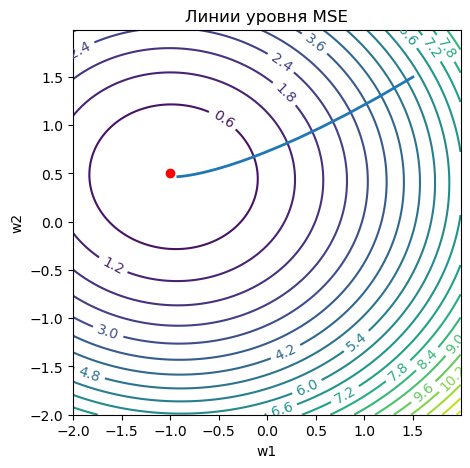

In [21]:
plot_gd(x_scale=1.0, lr=0.1, steps=25)

<img src="%2BTl5ufo6erx8vP09fb3%2BPn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3%2BPn6/9oADAMBAAIRAxEAPwD3%2BiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACivOk8PaN4k%2BKviX%2B1tMtb5LSyskT7REH2M3mMcZ6cY/SqXgzWZ9D%2BHngqG1jhKX%2BqvZSB1PyxlrhsrgjByg65HXigD1KiuC0bx3fa14v1KzhtrddGjsHubGchvMuNknll%2BuNhYNjjJABzzWe3xXtG%2BHVpq0Op6I/iCZLffYCcEhnkRXAjD7%2BFLHGeMc0Aem0Vx%2BoeNG0nW/EFvdxI9tptpay26Rg%2BbPLMZFEY5wSWVQMDvWXpvjjXJfDWmXl/a2Ed/Nr40m5jiVjGq%2BaY2K/Nndx1zj2oA9Eorh9I8bXmsfESXSILaAaH9lmaC6wfMnlidEcqc42ZcqOOSpOcVs%2BK9buvDtnZ6kkcL2CXcceoFwd0cLnb5ikHjaxUnIPGaAN%2BiuQ1DxVfJqviKGwit3s9E00zSySKxLXRUuqDBA2hACe/zDkVlW/i/xRa6HoniLVrTShpWoNbrNDbiQTQCbAWTcSQRlgSuMgHGTjNAHolFcSfEHifWdQ1keHbfS1tNKuGtMXokZ7qZVDOFKkBANwAJDZPaszUfiNNNb%2BFLqwvdI0m11u1nnln1dSyxNGI8ICJEGcuw98CgD0mivOf8AhYOop8PrrxDJFYb7fUktFuF3fZriIzIhmTJBC4ZsckZXuK1n8d6feeMdC0fRdT0vUIL0XBujbzrK8WxAyY2tgZOeoOccUAdhRXkmu/E7VrCDWriK98PWU2n3b28WlXqObuZVcKHH7xeGB3DCkY7163QAUV4V8P8AXG8EeDpiwMialYtf6fGf47pZPJaIf7xMBx/tNWh4a8Oava%2BDvHGhaRcu2rLfRgyiXY0r%2BVC0uH/hL/OAe26gD2WivNPDU/hOx8SWFtJ4TvvDesyBlt2uYiqTttO5RIrFZDjP3ufxxWJomnaRdal4mkvvANxrk39u3Y%2B1xwWzjG/7uZJFbj6Y5oA9moqG0jjisoI4oPs8aRqqQ4A8sAcLgccdOKmoAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiis3xBqh0Pw5qerCETGytZbjyi23fsUtjODjOPSgDSorkrbXvFV3cXFvDoOjtJbkCRv7Wk2AkZ2hvs/LDuMcZHPpXv/FniHS7kW97omlrI0fmL5eozyAgHBGRbdfb%2BVVytuwuZJXO1orkNM8QeKtYsUvbPQdJ8iT7vnanNG35fZv5Ej3pkeuePHOG8F6eg9W1of0iNKz2C63OyormI9Q8auPm8OaKn%2B9rMn9Lc1J9t8Z/9AHQ/wDwcS//ACNSGdHRXOfbfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAdHRXOfbfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAdHRXOfbfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAdHTZA7RsI2COQQrEZwfXHeue%2B2%2BM/8AoA6H/wCDiX/5Go%2B2%2BM/%2BgDof/g4l/wDkagCfw34cGgi9nnvZb/Ur%2BYTXd3KoUyMFCqAo4VQBgCucu/hm114J0fw2utyQf2fetdNdRQYaRW83cgG75DiUjdk4xnFbn23xn/0AdD/8HEv/AMjUfbfGf/QB0P8A8HEv/wAjUAKnhOCDXl1C1lWC3TSf7LjtVi4RQ%2B4MDnsOMY/Gs%2BTwBC/w7tfCovEWSBIE%2B2/ZhlvLkV87d3fbjrxnvV/7b4z/AOgDof8A4OJf/kaj7b4z/wCgDof/AIOJf/kagCtN4HiufiD/AMJRcXrSRLFGEsfLwolTcFkLZ5IEj4GOCc54qhqPw6kvfDUmkQ629rI2rvqi3Udv8yFpGfaBu6jdjd7ZxWs1940UZHh/RG9hrEv/AMjVVl1nx1H93wfpsn%2B5rX%2BMIp2C5etPCVrp%2BvaZf2UghttP059PitQn8LMjBt2e2z05znNT%2BK57aLw3eRXen3l/DcxtA1taQNK77lIxhQcD/aPA4rnZvFXjyD73gGE/7mrhv5RGqEnxC8YQHE3gF4x/eN3KR%2BYgqlCT2Jc4rcu6H4YvNC%2BEd9p9wstxq93YzzXWPneSd4z8vHUgbV4/u1DoPgnU7vw54ctdX1qZtMs4ra4/s57QJL5iKGWOSTPKq38O0H5QCTVUfFHUVYLcaTpdqx7TX9wP5Wpq/b%2BPtQuceXF4XGf%2BemuSp/6FbCh05roJVIvqaFz4O1KG/wBUm0LxC2mW%2BqP5t1C1oJispUKzxMWGwkAZyGGRmorvwE8X/CO/2FqEFiuiW01tGt1Z/aRIsgQEnDpg/JnPcmrUGteKboZt9L8OTD/pnrkjfyt6n%2B2%2BM/8AoA6H/wCDiX/5GqCzK/4V3u8N6hpkuqhp7/UYtQnmW1CRhkeNtqRBsKCIwOpOSSc1t33hqK68TaLrMcqQf2YJwYliH73zUC9cjGMZ6HPtUP23xn/0AdD/APBxL/8AI1H23xn/ANAHQ/8AwcS//I1AGdqXw/XVtG1yC81ESanq7qXvjb58mNWBSNE3cKoGPvckknriu0rnPtvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoAh0TwLpmneH9F02/SPUZdIkM1tcPHsKybiwYDJx19T0qW38MXVkdflstXa3udVvFukmW3VjBhUXbhiQwITnpw340G%2B8aAEjQNDJ9BrEvP8A5LVlXnifx1Z5LeBbaVR/FDqxfP4CHP6U0ribS3Lg8Janf6zpt9r%2BvJfR6bKZ7e3t7IW6mXaVDOd7E4BPAwKhsfCniLSLnUzpfiOwit76/mvfLn0ppGRpDkruEy5A47CsdPiXrKyCO90HTtPkP8N3fzof0tjW3ZeJPEOogfYrDw1OT2j12Qn8vs%2BabhJbomNSMtmdZbrMltEtxIss4QCSRE2KzY5IXJwCe2Tj1NSVzn23xn/0AdD/APBxL/8AI1H23xn/ANAHQ/8AwcS//I1SWdHRXOfbfGf/AEAdD/8ABxL/API1Ib7xoASNA0Mn0GsS8/8AktQB0lFcDfeL/GunHM/geAoP%2BWkWptIoHr8sJxSWHjzVtRbZFZeHkk6eXNrE0bZ9MNbDP4VXK7XI9rC9m9Tv6K5sX3jMgEaFoRB6EaxL/wDI1L9t8Z/9AHQ//BxL/wDI1SWdHRXN/bfGf/QB0L/wcS//ACNVW91

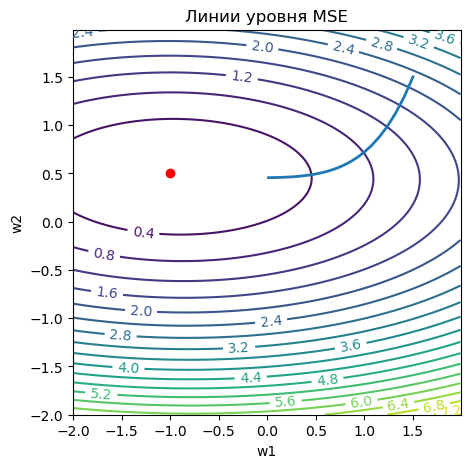

In [22]:
# узкие долины функции
plot_gd(x_scale=0.5, lr=0.1, steps=25)

<img src="%2BTl5ufo6erx8vP09fb3%2BPn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3%2BPn6/9oADAMBAAIRAxEAPwD3%2BiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACivOk8PaN4k%2BKviX%2B1tMtb5LSyskT7REH2M3mMcZ6cY/SqXgzWZ9D%2BHngqG1jhKX%2BqvZSB1PyxlrhsrgjByg65HXigD1KiuC0bx3fa14v1KzhtrddGjsHubGchvMuNknll%2BuNhYNjjJABzzWe3xXtG%2BHVpq0Op6I/iCZLffYCcEhnkRXAjD7%2BFLHGeMc0Aem0Vx%2BoeNG0nW/EFvdxI9tptpay26Rg%2BbPLMZFEY5wSWVQMDvWXpvjjXJfDWmXl/a2Ed/Nr40m5jiVjGq%2BaY2K/Nndx1zj2oA9Eorh9I8bXmsfESXSILaAaH9lmaC6wfMnlidEcqc42ZcqOOSpOcVs%2BK9buvDtnZ6kkcL2CXcceoFwd0cLnb5ikHjaxUnIPGaAN%2BiuQ1DxVfJqviKGwit3s9E00zSySKxLXRUuqDBA2hACe/zDkVlW/i/xRa6HoniLVrTShpWoNbrNDbiQTQCbAWTcSQRlgSuMgHGTjNAHolFcSfEHifWdQ1keHbfS1tNKuGtMXokZ7qZVDOFKkBANwAJDZPaszUfiNNNb%2BFLqwvdI0m11u1nnln1dSyxNGI8ICJEGcuw98CgD0mivOf8AhYOop8PrrxDJFYb7fUktFuF3fZriIzIhmTJBC4ZsckZXuK1n8d6feeMdC0fRdT0vUIL0XBujbzrK8WxAyY2tgZOeoOccUAdhRXkmu/E7VrCDWriK98PWU2n3b28WlXqObuZVcKHH7xeGB3DCkY7163QAUV4V8P8AXG8EeDpiwMialYtf6fGf47pZPJaIf7xMBx/tNWh4a8Oava%2BDvHGhaRcu2rLfRgyiXY0r%2BVC0uH/hL/OAe26gD2WivNPDU/hOx8SWFtJ4TvvDesyBlt2uYiqTttO5RIrFZDjP3ufxxWJomnaRdal4mkvvANxrk39u3Y%2B1xwWzjG/7uZJFbj6Y5oA9moqG0jjisoI4oPs8aRqqQ4A8sAcLgccdOKmoAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiis3xBqh0Pw5qerCETGytZbjyi23fsUtjODjOPSgDSormxfeMyAf7B0Pn/qMS/wDyNS/bfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1H23xn/wBAHQ//AAcS/wDyNQB0dFc59t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAdHRXOfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1H23xn/wBAHQ//AAcS/wDyNQB0dFc59t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAdHTZA7RsI2COQQrEZwfXHeue%2B2%2BM/wDoA6H/AODiX/5Go%2B2%2BM/8AoA6H/wCDiX/5GoAn8N%2BHBoIvZ572W/1K/mE13dyqFMjBQqgKOFUAYArnLv4ZtdeCdH8NrrckH9n3rXTXUUGGkVvN3IBu%2BQ4lI3ZOMZxW59t8Z/8AQB0P/wAHEv8A8jUfbfGf/QB0P/wcS/8AyNQAqeE4INeXULWVYLdNJ/suO1WLhFD7gwOew4xj8az5PAEL/Du18Ki8RZIEgT7b9mGW8uRXzt3d9uOvGe9X/tvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoArTeB4rn4g/8JRcXrSRLFGEsfLwolTcFkLZ5IEj4GOCc54qhqPw6kvfDUmkQ629rI2rvqi3Udv8yFpGfaBu6jdjd7ZxWx9t8Z/9AHQ//BxL/wDI1H23xn/0AdD/APBxL/8AI1ADrTwla6fr2mX9lIIbbT9OfT4rUJ/CzIwbdnts9Oc5zU/iue2i8N3kV3p95fw3MbQNbWkDSu%2B5SMYUHA/2jwOKrfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AGJofhi80L4R32n3Cy3Gr3djPNdY%2Bd5J3jPy8dSBtXj%2B7UOg%2BCdTu/Dnhy11fWpm0yzitrj%2BzntAkvmIoZY5JM8qrfw7QflAJNdD9t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAU7nwdqUN/qk2heIW0y31R/NuoWtBMVlKhWeJiw2EgDOQwyM1Fd%2BAni/4R3%2BwtQgsV0S2mto1urP7SJFkCAk4dMH5M57k1o/bfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAZX/AArvd4b1DTJdVDT3%2BoxahPMtqEjDI8bbUiDYUERgdSckk5rbvvDUV14m0XWY5Ug/swTgxLEP3vmoF65GMYz0OfaoftvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoAztS%2BH66to2uQXmoiTU9XdS98bfPkxqwKRom7hVAx97kkk9cV2lc2b7xoBxoGhn6axL/wDI1RtqXjYdPDWjt9NZf/5HoATRPAumad4f0XTb9I9Rl0iQzW1w8ewrJuLBgMnHX1PSpbfwxdWR1%2BWy1dre51W8W6SZbdWMGFRduGJDAhOenDfjVZtX8cjp4S0tvprR/wDjNRtrnjwdPBent9NbH/xqnYVyQeEtTv8AWdNvtf15L6PTZTPb29vZC3Uy7SoZzvYnAJ4GBUNj4U8RaRc6mdL8R2EVvfX8175c%2BlNIyNIcldwmXIHHYVG3iHx8v/MiWh%2BmtKf/AGnUTeKvHadfAUP4atn%2BUVPlYudHcW6zJbRLcSLLOEAkkRNis2OSFycAntk49TUleet4z8cJ18AD8NRY/wAoam07xZ401C8FsfBMFrlSfNudQlROO2fIPNHKxKpG9jvKK5G%2B17xXpyRtPoWjM8jBI4o9WlZ5G9FH2fn%2BXqRVs3vjHPyaDou3tv1eQH8QLcj9TSt1Kur2OjorgIvH2pzPbRjTtGWW4Yxqj6rIu1ufvZgyAex65IGBWjqGv%2BKNKtDdX2kaDDACFLtq8xGT06W1Nxa0aJU4tXTOuorz9PH%2BoP0h8Mj/AHtalH87arCeM9Vk%2B7H4T/HxAw/9t6OWXYPaQfU7iiuPTxL4gk%2B5Z%2BF2/wB3X3P/ALb1YTVvFkn%2Br0jw8/8Au61If/balZlXTOoornPtvjP/AKAOh/8Ag4l/%2BRqPtvjP/oA6H/4OJf8

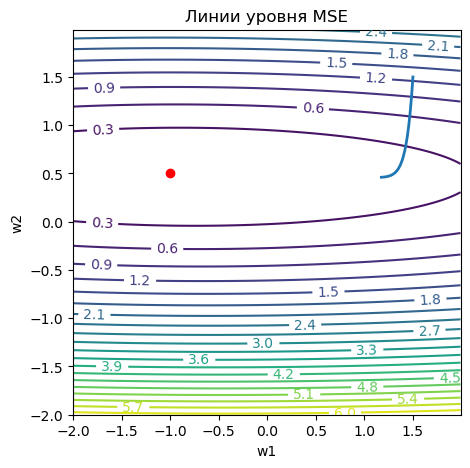

In [23]:
# еще более узкие
plot_gd(x_scale=0.2, lr=0.1, steps=25)

<img src="%2BTl5ufo6erx8vP09fb3%2BPn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3%2BPn6/9oADAMBAAIRAxEAPwD3%2BiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACivOk8PaN4k%2BKviX%2B1tMtb5LSyskT7REH2M3mMcZ6cY/SqXgzWZ9D%2BHngqG1jhKX%2BqvZSB1PyxlrhsrgjByg65HXigD1KiuC0bx3fa14v1KzhtrddGjsHubGchvMuNknll%2BuNhYNjjJABzzWe3xXtG%2BHVpq0Op6I/iCZLffYCcEhnkRXAjD7%2BFLHGeMc0Aem0Vx%2BoeNG0nW/EFvdxI9tptpay26Rg%2BbPLMZFEY5wSWVQMDvWXpvjjXJfDWmXl/a2Ed/Nr40m5jiVjGq%2BaY2K/Nndx1zj2oA9Eorh9I8bXmsfESXSILaAaH9lmaC6wfMnlidEcqc42ZcqOOSpOcVs%2BK9buvDtnZ6kkcL2CXcceoFwd0cLnb5ikHjaxUnIPGaAN%2BiuQ1DxVfJqviKGwit3s9E00zSySKxLXRUuqDBA2hACe/zDkVlW/i/xRa6HoniLVrTShpWoNbrNDbiQTQCbAWTcSQRlgSuMgHGTjNAHolFcSfEHifWdQ1keHbfS1tNKuGtMXokZ7qZVDOFKkBANwAJDZPaszUfiNNNb%2BFLqwvdI0m11u1nnln1dSyxNGI8ICJEGcuw98CgD0mivOf8AhYOop8PrrxDJFYb7fUktFuF3fZriIzIhmTJBC4ZsckZXuK1n8d6feeMdC0fRdT0vUIL0XBujbzrK8WxAyY2tgZOeoOccUAdhRXkmu/E7VrCDWriK98PWU2n3b28WlXqObuZVcKHH7xeGB3DCkY7163QAUV4V8P8AXG8EeDpiwMialYtf6fGf47pZPJaIf7xMBx/tNWh4a8Oava%2BDvHGhaRcu2rLfRgyiXY0r%2BVC0uH/hL/OAe26gD2WivNPDU/hOx8SWFtJ4TvvDesyBlt2uYiqTttO5RIrFZDjP3ufxxWJomnaRdal4mkvvANxrk39u3Y%2B1xwWzjG/7uZJFbj6Y5oA9moqG0jjisoI4oPs8aRqqQ4A8sAcLgccdOKmoAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiis3xBqh0Pw5qerCETGytZbjyi23fsUtjODjOPSgDSormxfeMyAf7B0Pn/qMS/wDyNS/bfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1H23xn/wBAHQ//AAcS/wDyNQB0dFc59t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAdHRXOfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1H23xn/wBAHQ//AAcS/wDyNQB0dFc59t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAdHTZA7RsI2COQQrEZwfXHeue%2B2%2BM/wDoA6H/AODiX/5Go%2B2%2BM/8AoA6H/wCDiX/5GoAn8N%2BHBoIvZ572W/1K/mE13dyqFMjBQqgKOFUAYArnLv4ZtdeCdH8NrrckH9n3rXTXUUGGkVvN3IBu%2BQ4lI3ZOMZxW59t8Z/8AQB0P/wAHEv8A8jUfbfGf/QB0P/wcS/8AyNQAqeE4INeXULWVYLdNJ/suO1WLhFD7gwOew4xj8az5PAEL/Du18Ki8RZIEgT7b9mGW8uRXzt3d9uOvGe9Ra54r8U%2BH7aGe78PaQ6TTCFRFq0hO4gnnNuOOKNd8V%2BKfD1nFdXfh7SHSSYQqItWkJ3EE97cccGrUJO1luQ6kVe72Lc3geK5%2BIP8AwlFxetJEsUYSx8vCiVNwWQtnkgSPgY4JzniqGo/DqS98NSaRDrb2sjau%2BqLdR2/zIWkZ9oG7qN2N3tnFZmqfE3XdIv7mzuPDWntJbuqOY9VcgkjIxmAVqWni/wAT3muPpEfh3SRcJbi4LNq0m3advGfs%2Bc/MO1N0ZpXaJVam3ZPU2bTwla6fr2mX9lIIbbT9OfT4rUJ/CzIwbdnts9Oc5zU/iue2i8N3kV3p95fw3MbQNbWkDSu%2B5SMYUHA/2jwOK5my8ceJb/RL7VovDuli3s2dZFbVpAxKgE4H2fHf1qR/GXidPDA18%2BHdK%2BybA%2B3%2B1pN%2BC23p9nx196Xsp3tbyH7WDV7%2BfyG6H4YvNC%2BEd9p9wstxq93YzzXWPneSd4z8vHUgbV4/u1DoPgnU7vw54ctdX1qZtMs4ra4/s57QJL5iKGWOSTPKq38O0H5QCTV%2BfxP4qt/D41p/D2kG28hZ9o1eTftYAjj7PjPPrViw1vxdqOmwX0OgaKIpoxIofV5QwBGef9HpOLSuUpxbtcbc%2BDtShv8AVJtC8Qtplvqj%2BbdQtaCYrKVCs8TFhsJAGchhkZqK78BPF/wjv9hahBYroltNbRrdWf2kSLIEBJw6YPyZz3Jpmg%2BKvFPiHTvt1p4e0hIt5TEurSA5GPS3PrVLTfH3iLVNen0eDw5pi3EJcMz6q4T5Tg4Igz%2BlP2c9dNtyfaw0d99i5/wrvd4b1DTJdVDT3%2BoxahPMtqEjDI8bbUiDYUERgdSckk5rbvvDUV14m0XWY5Ug/swTgxLEP3vmoF65GMYz0OfaqGoa14v03T7i9m0DRTFBGZGCavKSQPT/AEem6Zrvi7VtNgv4PD%2BjLFOu5Q%2BryhgPfFuanlduboXzK/L1IdS%2BH66to2uQXmoiTU9XdS98bfPkxqwKRom7hVAx97kkk9cV2lcPrHivxToj2aXPh7SXN3MIY/L1aQ4Y%2Bubccc1oNqXjYdPDWjt9NZf/AOR6HFpJ9xKSba7CaJ4F0zTvD%2Bi6bfpHqMukSGa2uHj2FZNxYMBk46%2Bp6VLb%2BGLqyOvy2Wrtb3Oq3i3STLbqxgwqLtwxIYEJz04b8axtT8Y%2BLdJurK3ufCum%2BZey%2BVCE1djlsgc/ueOoq42uePB08F6e301sf/Gqbg0kw54ttdiQeEtTv9Z02%2B1/Xkvo9NlM9vb29kLdTLtKhnO9icAngYFQ2PhTxFpFzqZ0vxHYRW99fzXvlz6U0jI0hyV3CZcgcdhVHU/GnjLRrM3d/wCCrOKAEKX/ALZDcnpwIiaePFvjkorjwHCVYZBGrZyP%2B/VPkla4vaRvY7q3WZLaJbiRZZwgEkiJsVmxyQuTgE9snHqakrz1vGfjhOvgAfhqLH%2BUNNsPHfiq%2B

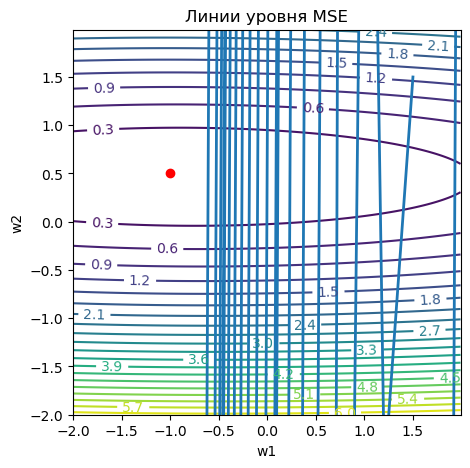

In [24]:
# попробуем шаг побольше?
# w0 меняется быстрее, но w1 меняется слишком быстро, приводит к осциллированию
plot_gd(x_scale=0.2, lr=2.0, steps=25)

# Adam

Адам работает как зайка, ему не важен масштаб признаков, у него адаптивный learning rate и инерция!

<img src="%2BTl5ufo6erx8vP09fb3%2BPn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3%2BPn6/9oADAMBAAIRAxEAPwD3%2BiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACivOk8PaN4k%2BKviX%2B1tMtb5LSyskT7REH2M3mMcZ6cY/SqXgzWZ9D%2BHngqG1jhKX%2BqvZSB1PyxlrhsrgjByg65HXigD1KiuC0bx3fa14v1KzhtrddGjsHubGchvMuNknll%2BuNhYNjjJABzzWe3xXtG%2BHVpq0Op6I/iCZLffYCcEhnkRXAjD7%2BFLHGeMc0Aem0Vx%2BoeNG0nW/EFvdxI9tptpay26Rg%2BbPLMZFEY5wSWVQMDvWXpvjjXJfDWmXl/a2Ed/Nr40m5jiVjGq%2BaY2K/Nndx1zj2oA9Eorh9I8bXmsfESXSILaAaH9lmaC6wfMnlidEcqc42ZcqOOSpOcVs%2BK9buvDtnZ6kkcL2CXcceoFwd0cLnb5ikHjaxUnIPGaAN%2BiuQ1DxVfJqviKGwit3s9E00zSySKxLXRUuqDBA2hACe/zDkVlW/i/xRa6HoniLVrTShpWoNbrNDbiQTQCbAWTcSQRlgSuMgHGTjNAHolFcSfEHifWdQ1keHbfS1tNKuGtMXokZ7qZVDOFKkBANwAJDZPaszUfiNNNb%2BFLqwvdI0m11u1nnln1dSyxNGI8ICJEGcuw98CgD0mivOf8AhYOop8PrrxDJFYb7fUktFuF3fZriIzIhmTJBC4ZsckZXuK1n8d6feeMdC0fRdT0vUIL0XBujbzrK8WxAyY2tgZOeoOccUAdhRXkmu/E7VrCDWriK98PWU2n3b28WlXqObuZVcKHH7xeGB3DCkY7163QAUV4V8P8AXG8EeDpiwMialYtf6fGf47pZPJaIf7xMBx/tNWh4a8Oava%2BDvHGhaRcu2rLfRgyiXY0r%2BVC0uH/hL/OAe26gD2WivNPDU/hOx8SWFtJ4TvvDesyBlt2uYiqTttO5RIrFZDjP3ufxxWJomnaRdal4mkvvANxrk39u3Y%2B1xwWzjG/7uZJFbj6Y5oA9moqG0jjisoI4oPs8aRqqQ4A8sAcLgccdOKmoAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiis3xBqh0Pw5qerCETGytZbjyi23fsUtjODjOPSgDSorlrbU/G1xbpK/hrR4Cwz5cusPuH1225H61N9t8Z/8AQB0P/wAHEv8A8jUAdHRXOfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1UdQ8TeINKXdf2Phq27gS67IpP0H2fJppN7AdjRXlx%2BKesSymPTvDlnqbg4Isr2d/52wrWs/FPjy8AI8BQQqe82rhMfgYs/pVOnJboLnd0VzSX/jRlBPh/REPodYkyPyt6d9t8Z/8AQB0P/wAHEv8A8jVAHR0Vzn23xn/0AdD/APBxL/8AI1H23xn/ANAHQ/8AwcS//I1AHR02QO0bCNgjkEKxGcH1x3rnvtvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoAn8N%2BHBoIvZ572W/wBSv5hNd3cqhTIwUKoCjhVAGAK5y7%2BGbXXgnR/Da63JB/Z961011FBhpFbzdyAbvkOJSN2TjGcVufbfGf8A0AdD/wDBxL/8jVXudV8cQDMfhXSbg%2BkWssP/AEKAUAWU8JwQa8uoWsqwW6aT/ZcdqsXCKH3Bgc9hxjH41nyeAIX%2BHdr4VF4iyQJAn237MMt5civnbu77cdeM96ybzx541sD/AKT8PiFHV01BpFH1KQmm2XxNvbyTyvsmgW8o4Md1q00RH1LW2P1q/ZztewXN6bwPFc/EH/hKLi9aSJYowlj5eFEqbgshbPJAkfAxwTnPFUNR%2BHUl74ak0iHW3tZG1d9UW6jt/mQtIz7QN3UbsbvbOK1IdU8XXEQlg0bw/LGejprUjA/iLapPtvjP/oA6H/4OJf8A5GqAHWnhK10/XtMv7KQQ22n6c%2BnxWoT%2BFmRg27PbZ6c5zmp/Fc9tF4bvIrvT7y/huY2ga2tIGld9ykYwoOB/tHgcVW%2B2%2BM/%2BgDof/g4l/wDkaj7b4z/6AOh/%2BDiX/wCRqAMTQ/DF5oXwjvtPuFluNXu7Gea6x87yTvGfl46kDavH92odB8E6nd%2BHPDlrq%2BtTNplnFbXH9nPaBJfMRQyxySZ5VW/h2g/KASa6H7b4z/6AOh/%2BDiX/AORqyNZ8V%2BMtETzZvB1nPbj701tqjuqfUeRuA98U0m3ZAW7nwdqUN/qk2heIW0y31R/NuoWtBMVlKhWeJiw2EgDOQwyM1Fd%2BAni/4R3%2BwtQgsV0S2mto1urP7SJFkCAk4dMH5M57k0uk%2BKfEOuW3n6bpvh64T%2BILrMoZfqptsj8a0PtvjP8A6AOh/wDg4l/%2BRqGmnZgZX/Cu93hvUNMl1UNPf6jFqE8y2oSMMjxttSINhQRGB1JySTmtu%2B8NRXXibRdZjlSD%2BzBODEsQ/e%2BagXrkYxjPQ59qh%2B2%2BM/8AoA6H/wCDiX/5Gqtfav42s7R508L6VdFeTHBq8hcj2BtxmkBX1L4frq2ja5BeaiJNT1d1L3xt8%2BTGrApGibuFUDH3uSST1xXaVxGieLPEuv2zzWeh6MGjbZLFLqsyvE3ow%2BzVfk1XxbC8aSaN4fR5DtRW1qUFj6D/AEbmm007MSaauJongXTNO8P6Lpt%2Bkeoy6RIZra4ePYVk3FgwGTjr6npUtv4YurI6/LZau1vc6reLdJMturGDCou3DEhgQnPThvxpftvjP/oA6H/4OJf/AJGrFi8Z%2BJm1ttIufDulWd31iFzq0irMP9hhbkH%2BdCTewNpbmgPCWp3%2Bs6bfa/ryX0emyme3t7eyFupl2lQznexOATwMCobHwp4i0i51M6X4jsIre%2Bv5r3y59KaRkaQ5K7hMuQOOwrQ%2B2%2BM/%2BgDof/g4l/8Akaka%2B8aBSRoGhkgdBrEvP/ktSGdBbrMltEtxIss4QCSRE2KzY5IXJwCe2Tj1NSVw2leLvE%2Bq3VxZr4f0m3vLc4ktrjVpFcD1GLcgj3B/mK1vtvjP/oA6H/4OJf8A5GptNbiUlJXR0dFcTrHifxZocMdxdeG9La3ZgrzRarIyxZ7t/o%2BcfQGtCLUvGE8SSxaJoLxuAysusykEHuP9Gos7XBSTdup01Fcvc6n40t7aSYeG9HmKLu8uLV5Cz

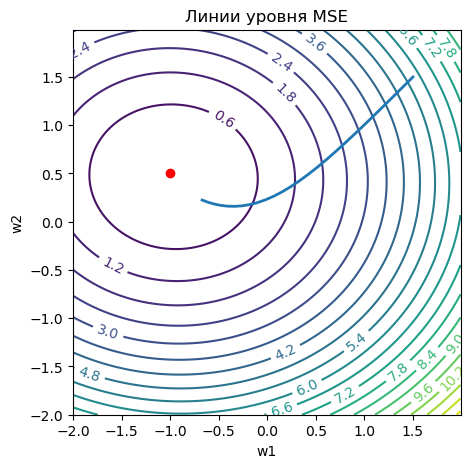

In [25]:
plot_gd(x_scale=1.0, lr=0.1, steps=25, optimizer='adam')

<img src="%2BTl5ufo6erx8vP09fb3%2BPn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3%2BPn6/9oADAMBAAIRAxEAPwD3%2BiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACivOk8PaN4k%2BKviX%2B1tMtb5LSyskT7REH2M3mMcZ6cY/SqXgzWZ9D%2BHngqG1jhKX%2BqvZSB1PyxlrhsrgjByg65HXigD1KiuC0bx3fa14v1KzhtrddGjsHubGchvMuNknll%2BuNhYNjjJABzzWe3xXtG%2BHVpq0Op6I/iCZLffYCcEhnkRXAjD7%2BFLHGeMc0Aem0Vx%2BoeNG0nW/EFvdxI9tptpay26Rg%2BbPLMZFEY5wSWVQMDvWXpvjjXJfDWmXl/a2Ed/Nr40m5jiVjGq%2BaY2K/Nndx1zj2oA9Eorh9I8bXmsfESXSILaAaH9lmaC6wfMnlidEcqc42ZcqOOSpOcVs%2BK9buvDtnZ6kkcL2CXcceoFwd0cLnb5ikHjaxUnIPGaAN%2BiuQ1DxVfJqviKGwit3s9E00zSySKxLXRUuqDBA2hACe/zDkVlW/i/xRa6HoniLVrTShpWoNbrNDbiQTQCbAWTcSQRlgSuMgHGTjNAHolFcSfEHifWdQ1keHbfS1tNKuGtMXokZ7qZVDOFKkBANwAJDZPaszUfiNNNb%2BFLqwvdI0m11u1nnln1dSyxNGI8ICJEGcuw98CgD0mivOf8AhYOop8PrrxDJFYb7fUktFuF3fZriIzIhmTJBC4ZsckZXuK1n8d6feeMdC0fRdT0vUIL0XBujbzrK8WxAyY2tgZOeoOccUAdhRXkmu/E7VrCDWriK98PWU2n3b28WlXqObuZVcKHH7xeGB3DCkY7163QAUV4V8P8AXG8EeDpiwMialYtf6fGf47pZPJaIf7xMBx/tNWh4a8Oava%2BDvHGhaRcu2rLfRgyiXY0r%2BVC0uH/hL/OAe26gD2WivNPDU/hOx8SWFtJ4TvvDesyBlt2uYiqTttO5RIrFZDjP3ufxxWJomnaRdal4mkvvANxrk39u3Y%2B1xwWzjG/7uZJFbj6Y5oA9moqG0jjisoI4oPs8aRqqQ4A8sAcLgccdOKmoAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiis3xBqh0Pw5qerCETGytZbjyi23fsUtjODjOPSgDSorkrbXvFV3cXFvDoOjtJbkCRv7Wk2AkZ2hvs/LDuMcZHPpXv/FniHS7kW97omlrI0fmL5eozyAgHBGRbdfb%2BVVytuwuZJXO1orkNM8QeKtYsUvbPQdJ8iT7vnanNG35fZv5Ej3pkeuePHOG8F6eg9W1of0iNKz2C63OyormI9Q8auPm8OaKn%2B9rMn9Lc1J9t8Z/9AHQ/wDwcS//ACNSGdHRXOfbfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAdHRXOfbfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAdHRXOfbfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAdHTZA7RsI2COQQrEZwfXHeue%2B2%2BM/8AoA6H/wCDiX/5Go%2B2%2BM/%2BgDof/g4l/wDkagCfw34cGgi9nnvZb/Ur%2BYTXd3KoUyMFCqAo4VQBgCucu/hm114J0fw2utyQf2fetdNdRQYaRW83cgG75DiUjdk4xnFbn23xn/0AdD/8HEv/AMjUfbfGf/QB0P8A8HEv/wAjUAKnhOCDXl1C1lWC3TSf7LjtVi4RQ%2B4MDnsOMY/Gs%2BTwBC/w7tfCovEWSBIE%2B2/ZhlvLkV87d3fbjrxnvV/7b4z/AOgDof8A4OJf/kaj7b4z/wCgDof/AIOJf/kagCtN4HiufiD/AMJRcXrSRLFGEsfLwolTcFkLZ5IEj4GOCc54qhqPw6kvfDUmkQ629rI2rvqi3Udv8yFpGfaBu6jdjd7ZxWs1940UZHh/RG9hrEv/AMjVVl1nx1H93wfpsn%2B5rX%2BMIp2C5etPCVrp%2BvaZf2UghttP059PitQn8LMjBt2e2z05znNT%2BK57aLw3eRXen3l/DcxtA1taQNK77lIxhQcD/aPA4rnZvFXjyD73gGE/7mrhv5RGqEnxC8YQHE3gF4x/eN3KR%2BYgqlCT2Jc4rcu6H4YvNC%2BEd9p9wstxq93YzzXWPneSd4z8vHUgbV4/u1DoPgnU7vw54ctdX1qZtMs4ra4/s57QJL5iKGWOSTPKq38O0H5QCTVUfFHUVYLcaTpdqx7TX9wP5Wpq/b%2BPtQuceXF4XGf%2BemuSp/6FbCh05roJVIvqaFz4O1KG/wBUm0LxC2mW%2BqP5t1C1oJispUKzxMWGwkAZyGGRmorvwE8X/CO/2FqEFiuiW01tGt1Z/aRIsgQEnDpg/JnPcmrUGteKboZt9L8OTD/pnrkjfyt6n%2B2%2BM/8AoA6H/wCDiX/5GqCzK/4V3u8N6hpkuqhp7/UYtQnmW1CRhkeNtqRBsKCIwOpOSSc1t33hqK68TaLrMcqQf2YJwYliH73zUC9cjGMZ6HPtUP23xn/0AdD/APBxL/8AI1H23xn/ANAHQ/8AwcS//I1AGdqXw/XVtG1yC81ESanq7qXvjb58mNWBSNE3cKoGPvckknriu0rnPtvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoAh0TwLpmneH9F02/SPUZdIkM1tcPHsKybiwYDJx19T0qW38MXVkdflstXa3udVvFukmW3VjBhUXbhiQwITnpw340G%2B8aAEjQNDJ9BrEvP8A5LVlXnifx1Z5LeBbaVR/FDqxfP4CHP6U0ribS3Lg8Janf6zpt9r%2BvJfR6bKZ7e3t7IW6mXaVDOd7E4BPAwKhsfCniLSLnUzpfiOwit76/mvfLn0ppGRpDkruEy5A47CsdPiXrKyCO90HTtPkP8N3fzof0tjW3ZeJPEOogfYrDw1OT2j12Qn8vs%2BabhJbomNSMtmdZbrMltEtxIss4QCSRE2KzY5IXJwCe2Tj1NSVzn23xn/0AdD/APBxL/8AI1H23xn/ANAHQ/8AwcS//I1SWdHRXOfbfGf/AEAdD/8ABxL/API1Ib7xoASNA0Mn0GsS8/8AktQB0lFcDfeL/GunHM/geAoP%2BWkWptIoHr8sJxSWHjzVtRbZFZeHkk6eXNrE0bZ9MNbDP4VXK7XI9rC9m9Tv6K5sX3jMgEaFoRB6EaxL/wDI1L9t8Z/9AHQ//BxL/wDI1SWdHRXN/bfGf/QB0L/wcS//ACNVW91

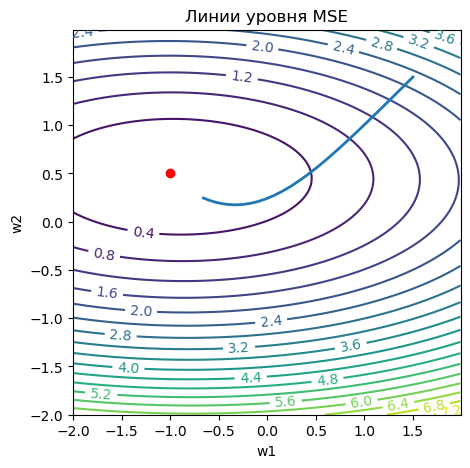

In [26]:
# узкие долины функции
plot_gd(x_scale=0.5, lr=0.1, steps=25, optimizer='adam')

<img src="%2BTl5ufo6erx8vP09fb3%2BPn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3%2BPn6/9oADAMBAAIRAxEAPwD3%2BiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACivOk8PaN4k%2BKviX%2B1tMtb5LSyskT7REH2M3mMcZ6cY/SqXgzWZ9D%2BHngqG1jhKX%2BqvZSB1PyxlrhsrgjByg65HXigD1KiuC0bx3fa14v1KzhtrddGjsHubGchvMuNknll%2BuNhYNjjJABzzWe3xXtG%2BHVpq0Op6I/iCZLffYCcEhnkRXAjD7%2BFLHGeMc0Aem0Vx%2BoeNG0nW/EFvdxI9tptpay26Rg%2BbPLMZFEY5wSWVQMDvWXpvjjXJfDWmXl/a2Ed/Nr40m5jiVjGq%2BaY2K/Nndx1zj2oA9Eorh9I8bXmsfESXSILaAaH9lmaC6wfMnlidEcqc42ZcqOOSpOcVs%2BK9buvDtnZ6kkcL2CXcceoFwd0cLnb5ikHjaxUnIPGaAN%2BiuQ1DxVfJqviKGwit3s9E00zSySKxLXRUuqDBA2hACe/zDkVlW/i/xRa6HoniLVrTShpWoNbrNDbiQTQCbAWTcSQRlgSuMgHGTjNAHolFcSfEHifWdQ1keHbfS1tNKuGtMXokZ7qZVDOFKkBANwAJDZPaszUfiNNNb%2BFLqwvdI0m11u1nnln1dSyxNGI8ICJEGcuw98CgD0mivOf8AhYOop8PrrxDJFYb7fUktFuF3fZriIzIhmTJBC4ZsckZXuK1n8d6feeMdC0fRdT0vUIL0XBujbzrK8WxAyY2tgZOeoOccUAdhRXkmu/E7VrCDWriK98PWU2n3b28WlXqObuZVcKHH7xeGB3DCkY7163QAUV4V8P8AXG8EeDpiwMialYtf6fGf47pZPJaIf7xMBx/tNWh4a8Oava%2BDvHGhaRcu2rLfRgyiXY0r%2BVC0uH/hL/OAe26gD2WivNPDU/hOx8SWFtJ4TvvDesyBlt2uYiqTttO5RIrFZDjP3ufxxWJomnaRdal4mkvvANxrk39u3Y%2B1xwWzjG/7uZJFbj6Y5oA9moqG0jjisoI4oPs8aRqqQ4A8sAcLgccdOKmoAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiis3xBqh0Pw5qerCETGytZbjyi23fsUtjODjOPSgDSormxfeMyAf7B0Pn/qMS/wDyNS/bfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1H23xn/wBAHQ//AAcS/wDyNQB0dFc59t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAdHRXOfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1H23xn/wBAHQ//AAcS/wDyNQB0dFc59t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAdHTZA7RsI2COQQrEZwfXHeue%2B2%2BM/wDoA6H/AODiX/5Go%2B2%2BM/8AoA6H/wCDiX/5GoAn8N%2BHBoIvZ572W/1K/mE13dyqFMjBQqgKOFUAYArnLv4ZtdeCdH8NrrckH9n3rXTXUUGGkVvN3IBu%2BQ4lI3ZOMZxW59t8Z/8AQB0P/wAHEv8A8jUfbfGf/QB0P/wcS/8AyNQAqeE4INeXULWVYLdNJ/suO1WLhFD7gwOew4xj8az5PAEL/Du18Ki8RZIEgT7b9mGW8uRXzt3d9uOvGe9X/tvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoArTeB4rn4g/8JRcXrSRLFGEsfLwolTcFkLZ5IEj4GOCc54qhqPw6kvfDUmkQ629rI2rvqi3Udv8yFpGfaBu6jdjd7ZxWx9t8Z/9AHQ//BxL/wDI1H23xn/0AdD/APBxL/8AI1ADrTwla6fr2mX9lIIbbT9OfT4rUJ/CzIwbdnts9Oc5zU/iue2i8N3kV3p95fw3MbQNbWkDSu%2B5SMYUHA/2jwOKrfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AGJofhi80L4R32n3Cy3Gr3djPNdY%2Bd5J3jPy8dSBtXj%2B7UOg%2BCdTu/Dnhy11fWpm0yzitrj%2BzntAkvmIoZY5JM8qrfw7QflAJNdD9t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAU7nwdqUN/qk2heIW0y31R/NuoWtBMVlKhWeJiw2EgDOQwyM1Fd%2BAni/4R3%2BwtQgsV0S2mto1urP7SJFkCAk4dMH5M57k1o/bfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAZX/AArvd4b1DTJdVDT3%2BoxahPMtqEjDI8bbUiDYUERgdSckk5rbvvDUV14m0XWY5Ug/swTgxLEP3vmoF65GMYz0OfaoftvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoAztS%2BH66to2uQXmoiTU9XdS98bfPkxqwKRom7hVAx97kkk9cV2lc2b7xoBxoGhn6axL/wDI1RtqXjYdPDWjt9NZf/5HoATRPAumad4f0XTb9I9Rl0iQzW1w8ewrJuLBgMnHX1PSpbfwxdWR1%2BWy1dre51W8W6SZbdWMGFRduGJDAhOenDfjVZtX8cjp4S0tvprR/wDjNRtrnjwdPBent9NbH/xqnYVyQeEtTv8AWdNvtf15L6PTZTPb29vZC3Uy7SoZzvYnAJ4GBUNj4U8RaRc6mdL8R2EVvfX8175c%2BlNIyNIcldwmXIHHYVG3iHx8v/MiWh%2BmtKf/AGnUTeKvHadfAUP4atn%2BUVPlYudHcW6zJbRLcSLLOEAkkRNis2OSFycAntk49TUleet4z8cJ18AD8NRY/wAoam07xZ401C8FsfBMFrlSfNudQlROO2fIPNHKxKpG9jvKK5G%2B17xXpyRtPoWjM8jBI4o9WlZ5G9FH2fn%2BXqRVs3vjHPyaDou3tv1eQH8QLcj9TSt1Kur2OjorgIvH2pzPbRjTtGWW4Yxqj6rIu1ufvZgyAex65IGBWjqGv%2BKNKtDdX2kaDDACFLtq8xGT06W1Nxa0aJU4tXTOuorz9PH%2BoP0h8Mj/AHtalH87arCeM9Vk%2B7H4T/HxAw/9t6OWXYPaQfU7iiuPTxL4gk%2B5Z%2BF2/wB3X3P/ALb1YTVvFkn%2Br0jw8/8Au61If/balZlXTOoornPtvjP/AKAOh/8Ag4l/%2BRqPtvjP/oA6H/4OJf8

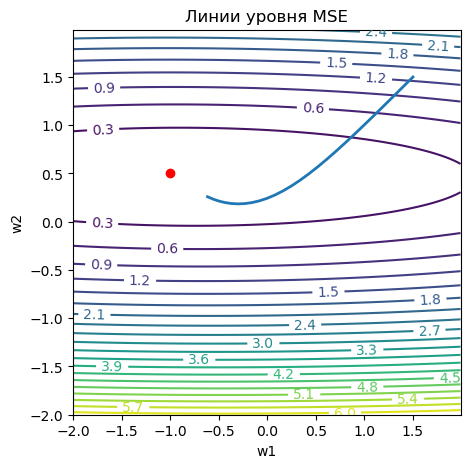

In [27]:
# еще более узкие
plot_gd(x_scale=0.2, lr=0.1, steps=25, optimizer='adam')

<img src="%2BTl5ufo6erx8vP09fb3%2BPn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3%2BPn6/9oADAMBAAIRAxEAPwD3%2BiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACivOk8PaN4k%2BKviX%2B1tMtb5LSyskT7REH2M3mMcZ6cY/SqXgzWZ9D%2BHngqG1jhKX%2BqvZSB1PyxlrhsrgjByg65HXigD1KiuC0bx3fa14v1KzhtrddGjsHubGchvMuNknll%2BuNhYNjjJABzzWe3xXtG%2BHVpq0Op6I/iCZLffYCcEhnkRXAjD7%2BFLHGeMc0Aem0Vx%2BoeNG0nW/EFvdxI9tptpay26Rg%2BbPLMZFEY5wSWVQMDvWXpvjjXJfDWmXl/a2Ed/Nr40m5jiVjGq%2BaY2K/Nndx1zj2oA9Eorh9I8bXmsfESXSILaAaH9lmaC6wfMnlidEcqc42ZcqOOSpOcVs%2BK9buvDtnZ6kkcL2CXcceoFwd0cLnb5ikHjaxUnIPGaAN%2BiuQ1DxVfJqviKGwit3s9E00zSySKxLXRUuqDBA2hACe/zDkVlW/i/xRa6HoniLVrTShpWoNbrNDbiQTQCbAWTcSQRlgSuMgHGTjNAHolFcSfEHifWdQ1keHbfS1tNKuGtMXokZ7qZVDOFKkBANwAJDZPaszUfiNNNb%2BFLqwvdI0m11u1nnln1dSyxNGI8ICJEGcuw98CgD0mivOf8AhYOop8PrrxDJFYb7fUktFuF3fZriIzIhmTJBC4ZsckZXuK1n8d6feeMdC0fRdT0vUIL0XBujbzrK8WxAyY2tgZOeoOccUAdhRXkmu/E7VrCDWriK98PWU2n3b28WlXqObuZVcKHH7xeGB3DCkY7163QAUV4V8P8AXG8EeDpiwMialYtf6fGf47pZPJaIf7xMBx/tNWh4a8Oava%2BDvHGhaRcu2rLfRgyiXY0r%2BVC0uH/hL/OAe26gD2WivNPDU/hOx8SWFtJ4TvvDesyBlt2uYiqTttO5RIrFZDjP3ufxxWJomnaRdal4mkvvANxrk39u3Y%2B1xwWzjG/7uZJFbj6Y5oA9moqG0jjisoI4oPs8aRqqQ4A8sAcLgccdOKmoAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiis3xBqh0Pw5qerCETGytZbjyi23fsUtjODjOPSgDSormxfeMyAf7B0Pn/qMS/wDyNS/bfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1H23xn/wBAHQ//AAcS/wDyNQB0dFc59t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAdHRXOfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AHR0Vzn23xn/ANAHQ/8AwcS//I1H23xn/wBAHQ//AAcS/wDyNQB0dFc59t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAdHTZA7RsI2COQQrEZwfXHeue%2B2%2BM/wDoA6H/AODiX/5Go%2B2%2BM/8AoA6H/wCDiX/5GoAn8N%2BHBoIvZ572W/1K/mE13dyqFMjBQqgKOFUAYArnLv4ZtdeCdH8NrrckH9n3rXTXUUGGkVvN3IBu%2BQ4lI3ZOMZxW59t8Z/8AQB0P/wAHEv8A8jUfbfGf/QB0P/wcS/8AyNQAqeE4INeXULWVYLdNJ/suO1WLhFD7gwOew4xj8az5PAEL/Du18Ki8RZIEgT7b9mGW8uRXzt3d9uOvGe9X/tvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoArTeB4rn4g/8JRcXrSRLFGEsfLwolTcFkLZ5IEj4GOCc54qhqPw6kvfDUmkQ629rI2rvqi3Udv8yFpGfaBu6jdjd7ZxWx9t8Z/9AHQ//BxL/wDI1H23xn/0AdD/APBxL/8AI1ADrTwla6fr2mX9lIIbbT9OfT4rUJ/CzIwbdnts9Oc5zU/iue2i8N3kV3p95fw3MbQNbWkDSu%2B5SMYUHA/2jwOKrfbfGf8A0AdD/wDBxL/8jUfbfGf/AEAdD/8ABxL/API1AGJofhi80L4R32n3Cy3Gr3djPNdY%2Bd5J3jPy8dSBtXj%2B7UOg%2BCdTu/Dnhy11fWpm0yzitrj%2BzntAkvmIoZY5JM8qrfw7QflAJNdD9t8Z/wDQB0P/AMHEv/yNR9t8Z/8AQB0P/wAHEv8A8jUAU7nwdqUN/qk2heIW0y31R/NuoWtBMVlKhWeJiw2EgDOQwyM1Fd%2BAni/4R3%2BwtQgsV0S2mto1urP7SJFkCAk4dMH5M57k1o/bfGf/AEAdD/8ABxL/API1H23xn/0AdD/8HEv/AMjUAZX/AArvd4b1DTJdVDT3%2BoxahPMtqEjDI8bbUiDYUERgdSckk5rbvvDUV14m0XWY5Ug/swTgxLEP3vmoF65GMYz0OfaoftvjP/oA6H/4OJf/AJGo%2B2%2BM/wDoA6H/AODiX/5GoAztS%2BH66to2uQXmoiTU9XdS98bfPkxqwKRom7hVAx97kkk9cV2lc2b7xoBxoGhn6axL/wDI1RtqXjYdPDWjt9NZf/5HoATRPAumad4f0XTb9I9Rl0iQzW1w8ewrJuLBgMnHX1PSpbfwxdWR1%2BWy1dre51W8W6SZbdWMGFRduGJDAhOenDfjVZtX8cjp4S0tvprR/wDjNRtrnjwdPBent9NbH/xqnYVyQeEtTv8AWdNvtf15L6PTZTPb29vZC3Uy7SoZzvYnAJ4GBUNj4U8RaRc6mdL8R2EVvfX8175c%2BlNIyNIcldwmXIHHYVG3iHx8v/MiWh%2BmtKf/AGnUTeKvHadfAUP4atn%2BUVPlYudHcW6zJbRLcSLLOEAkkRNis2OSFycAntk49TUleet4z8cJ18AD8NRY/wAoam07xZ401C8FsfBMFrlSfNudQlROO2fIPNHKxKpG9jvKK5G%2B17xXpyRtPoWjM8jBI4o9WlZ5G9FH2fn%2BXqRVs3vjHPyaDou3tv1eQH8QLcj9TSt1Kur2OjorgIvH2pzPbRjTtGWW4Yxqj6rIu1ufvZgyAex65IGBWjqGv%2BKNKtDdX2kaDDACFLtq8xGT06W1Nxa0aJU4tXTOuorz9PH%2BoP0h8Mj/AHtalH87arCeM9Vk%2B7H4T/HxAw/9t6OWXYPaQfU7iiuPTxL4gk%2B5Z%2BF2/wB3X3P/ALb1YTVvFkn%2Br0jw8/8Au61If/balZlXTOoornPtvjP/AKAOh/8Ag4l/%2BRqPtvjP/oA6H/4OJf8

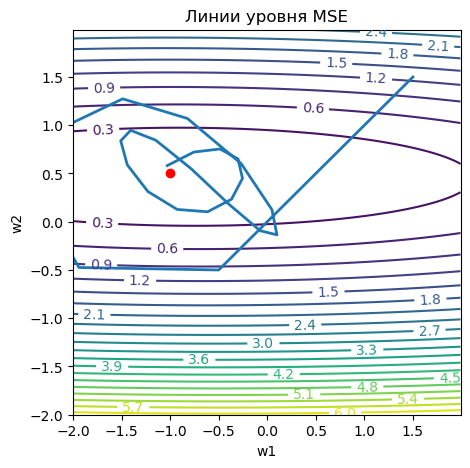

In [28]:
# сломает ли его шаг побольше?
# слишком большие шаги, закручиваемся вокруг решения из-за момента
plot_gd(x_scale=0.2, lr=2.0, steps=25, optimizer='adam')

Если хочется почитать подробнее: http://cnl.salk.edu/~schraudo/teach/NNcourse/precond.html